# Airbnb Open Data Analysis Report  
### A Data-Driven Exploration of New York City Airbnb Listings

### 基于数据的对纽约市爱彼迎房源的探索

**Author: Huang Xinyi**  
**Date: 06/03/2026**  

---

## Objective

The objective of this analysis is to explore the New York City Airbnb dataset and identify key patterns in listings, pricing, and neighborhood distribution. Through exploratory data analysis and visualization, this study aims to understand the popularity of different room types, price variations across locations, and other factors influencing Airbnb listings.

## 目地

本次分析的目的是对纽约市的爱彼迎数据集进行研究，并找出房源、定价和区域分布方面的关键模式。通过探索性数据分析和可视化手段，本研究旨在了解不同房型的受欢迎程度、不同地点的价格差异以及其他影响爱彼迎房源的因素。

# 1. Data Loading & Overview


In [6]:
#使用pandas库，读取数据，数据存在当前目录下
import pandas as pd 
data = pd. read_csv('listings_summary_2024_11.csv')

## 1.2 Data Structure

In [7]:
#查看数据的基本情况
data. info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37548 entries, 0 to 37547
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              37548 non-null  int64  
 1   name                            37546 non-null  object 
 2   host_id                         37548 non-null  int64  
 3   host_name                       37543 non-null  object 
 4   neighbourhood_group             37548 non-null  object 
 5   neighbourhood                   37548 non-null  object 
 6   latitude                        37548 non-null  float64
 7   longitude                       37548 non-null  float64
 8   room_type                       37548 non-null  object 
 9   price                           22741 non-null  float64
 10  minimum_nights                  37548 non-null  int64  
 11  number_of_reviews               37548 non-null  int64  
 12  last_review                     

In [8]:
#用 duplicated().sum()方法，查看是否存在重复值。可以看到没有重复值
duplicate_checking = data.duplicated().sum()

In [9]:
#打印了看看
duplicate_checking

np.int64(0)

In [10]:
#没有空值
print(int(duplicate_checking))

0


### 1.3 Missing Values
We check for missing values and decide how to handle them.


In [11]:
#通过 data.isnull().sum()方法，查看是否存在数据缺失情况。
missing_values = data. isnull(). sum()
missing_values

id                                    0
name                                  2
host_id                               0
host_name                             5
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                             14807
minimum_nights                        0
number_of_reviews                     0
last_review                       11560
reviews_per_month                 11560
calculated_host_listings_count        0
availability_365                      0
number_of_reviews_ltm                 0
license                           32194
dtype: int64

| 字段                | 缺失数量  | 说明               |
| ----------------- | ----- | ---------------- |
| name              | 2     | 有2条房源没有名称        |
| host_name         | 5     | 有5条房东没有名字        |
| price             | 14807 | 有14807条房源没有价格    |
| last_review       | 11560 | 有11560条房源没有评论日期  |
| reviews_per_month | 11560 | 有11560条房源没有每月评论数 |
| license           | 32194 | 有32194条房源没有许可证   |


In [12]:
data['name'] = data['name'].fillna('Unknown')
data['name'].isnull().sum()

np.int64(0)

In [13]:
data['host_name'] = data['host_name'].fillna('Unknown host')
data['host_name'].isnull().sum()

np.int64(0)

In [14]:
#因为 price 是核心变量：14807条没有价格 → 直接删除这些行。
#删除所有 price 为空（缺失）的房源数据
data = data.dropna(subset=['price'])
data['price'].isnull().sum()

np.int64(0)

In [15]:
#last_review原数据是日期格式，填充？好像不太确定可以填充什么
#保持 NaN 不处理

In [16]:
#处理 reviews_per_month没有评论说明 每月评论数 = 0 用0填充一下
data['reviews_per_month'] = data['reviews_per_month'].fillna(0)
data['reviews_per_month'].isnull().sum()

np.int64(0)

In [17]:
#license缺失 32194 太多了，直接删除这一列。
data = data.drop(columns=['license'])
data.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'number_of_reviews_ltm'],
      dtype='object')

In [18]:
#Missing Values After Data Cleaning
data.isnull().sum()

id                                   0
name                                 0
host_id                              0
host_name                            0
neighbourhood_group                  0
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                                0
minimum_nights                       0
number_of_reviews                    0
last_review                       6725
reviews_per_month                    0
calculated_host_listings_count       0
availability_365                     0
number_of_reviews_ltm                0
dtype: int64

## 1.4 data transformation

In [19]:
data.dtypes

id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                             float64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
number_of_reviews_ltm               int64
dtype: object

In [20]:
#last_review 现在是字符串类型（object），转换为时间类型。
data['last_review'] = pd.to_datetime(data['last_review'], errors='coerce')
data.dtypes

id                                         int64
name                                      object
host_id                                    int64
host_name                                 object
neighbourhood_group                       object
neighbourhood                             object
latitude                                 float64
longitude                                float64
room_type                                 object
price                                    float64
minimum_nights                             int64
number_of_reviews                          int64
last_review                       datetime64[ns]
reviews_per_month                        float64
calculated_host_listings_count             int64
availability_365                           int64
number_of_reviews_ltm                      int64
dtype: object

In [21]:
#skew值 0 完全对称 0 ~ 0.5 基本正常 0.5 ~ 1 轻度右偏 skew> 1 明显右偏 skew> 2 强烈右偏
data.skew(numeric_only=True)

id                                -0.056516
host_id                            0.539712
latitude                           0.105043
longitude                          1.006195
price                             22.819626
minimum_nights                     8.817164
number_of_reviews                  6.888283
reviews_per_month                 17.048411
calculated_host_listings_count     3.230554
availability_365                  -0.521438
number_of_reviews_ltm             33.019205
dtype: float64

In [22]:
#price 极度右偏（extremely right-skewed）做 log transformation
import numpy as np
data['log_price'] = np.log1p(data['price'])
data[['price','log_price']].head()

,price,log_price
0,240.0,5.484797
1,83.0,4.430817
2,65.0,4.189655
3,71.0,4.276666
5,205.0,5.327876


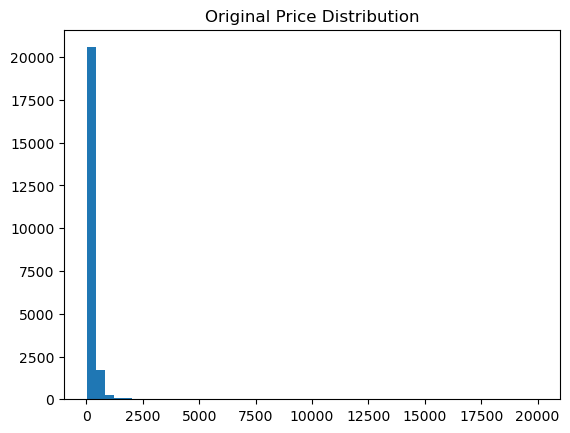

In [23]:
#数据看不太出来我们看看图对比吧
import matplotlib.pyplot as plt

plt.hist(data['price'], bins=50)
plt.title("Original Price Distribution")
plt.show()

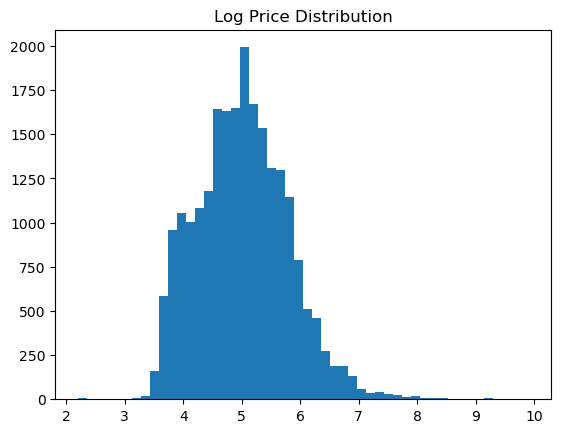

In [24]:
plt.hist(data['log_price'], bins=50)
plt.title("Log Price Distribution")
plt.show()

## 1.5 Feature Engineering（变量设计）

In [25]:
# Feature 1：Review Activity Level（评论活跃度）利用 reviews_per_month：每月评论数 × 12 = 每年评论数
#这样可以表示 房源受欢迎程度
data['review_activity'] = data['reviews_per_month'] * 12
data[['reviews_per_month','review_activity']].head()

,reviews_per_month,review_activity
0,0.27,3.24
1,1.04,12.48
2,0.03,0.36
3,1.37,16.44
5,2.16,25.92


In [26]:
#Feature 2：Availability Rate（房源可订比例）利用 availability_365创建新变量 availability_365（一年可订天数） / 365 = availability_rate（可订比例）
#说明房源 一年有多少时间可以预订。
data['availability_rate'] = data['availability_365'] / 365
data[['availability_365','availability_rate']].head()

,availability_365,availability_rate
0,365,1.000000
1,185,0.506849
2,83,0.227397
3,284,0.778082
5,215,0.589041


In [27]:
#Feature 3：Host Experience（房东经验）
#利用calculated_host_listings_count 房源 > 5 → 专业房东 房源 ≤ 5 → 个人房东
data['host_experience'] = data['calculated_host_listings_count'].apply(
    lambda x: 'Professional Host' if x > 5 else 'Individual Host'
)
data[['calculated_host_listings_count','host_experience']].head()

,calculated_host_listings_count,host_experience
0,3,Individual Host
1,1,Individual Host
2,2,Individual Host
3,1,Individual Host
5,2,Individual Host


## 1.6 Find anomalies with graphs 用图找异常


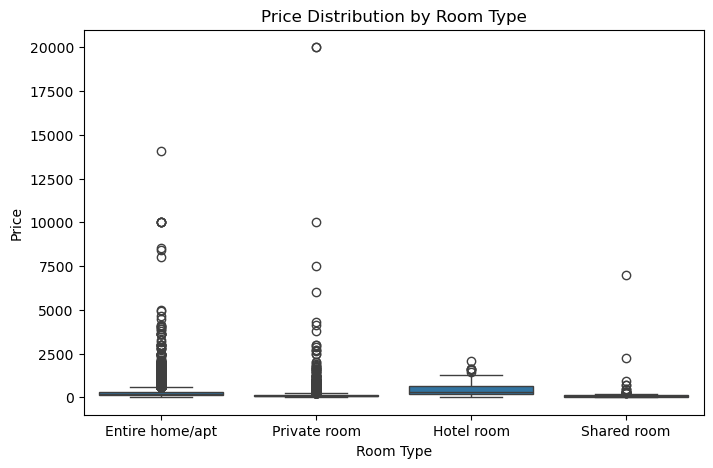

In [28]:
#Price vs Room Type看看有没有高的离谱的黑点可能是异常值
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x='room_type', y='price', data=data)

plt.title("Price Distribution by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price")
plt.show()

Private room ≈ 10000
Entire home ≈ 14000
Shared room ≈ 7000
所以这些可能是：数据错误/特殊豪宅

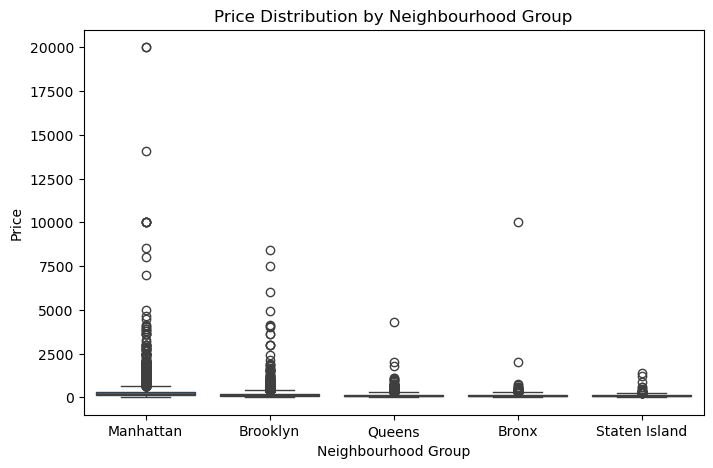

In [29]:
#不同区域价格差异price vs Neighbourhood Group
plt.figure(figsize=(8,5))
sns.boxplot(x='neighbourhood_group', y='price', data=data)

plt.title("Price Distribution by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Price")
plt.show()

Manhattan 有：10000、15000、20000
Bronx 有: 10000
这些可能是：豪宅、数据错误

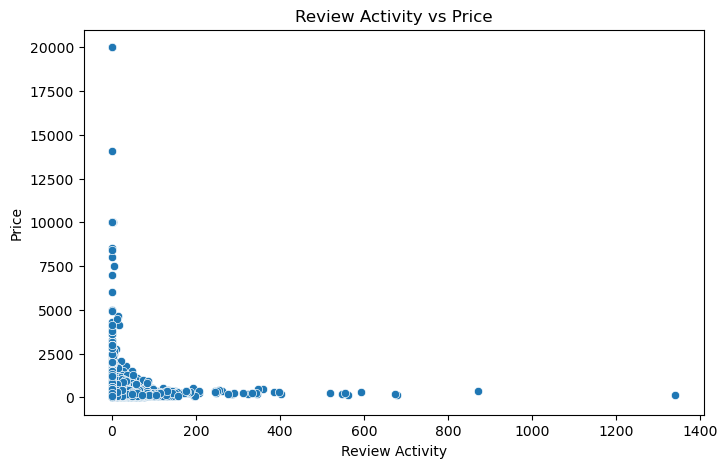

In [30]:
#评论活跃度 vs 价格 Review Activity vs Price
plt.figure(figsize=(8,5))
sns.scatterplot(x='review_activity', y='price', data=data)

plt.title("Review Activity vs Price")
plt.xlabel("Review Activity")
plt.ylabel("Price")
plt.show()

活跃度高的1400价格却为0？好多价格为0

## 1.7 Outlier processing异常值处理

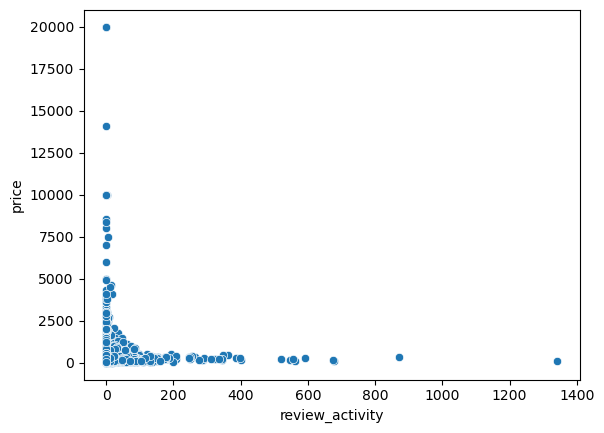

In [32]:
# 处理 price = 0 invalid data无效数据
#删除所有 price = 0 的记录
data = data[data['price'] > 0]
#图片展示
sns.scatterplot(x='review_activity', y='price', data=data)
plt.show()

图片展示不清楚可能只是价格很低，不是价格为0

In [34]:
#我们用数值看一看
(data['price'] == 0).sum()

np.int64(0)

In [35]:
#处理极端高价（outliers）
data = data[data['price'] < 5000]

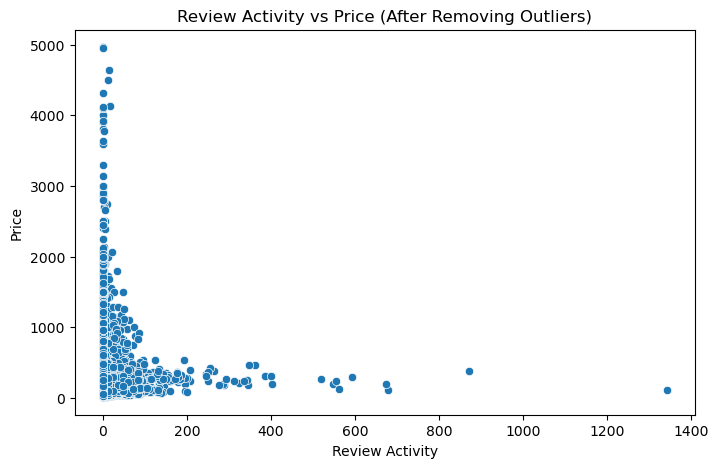

In [36]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='review_activity', y='price', data=data)

plt.title("Review Activity vs Price (After Removing Outliers)")
plt.xlabel("Review Activity")
plt.ylabel("Price")

plt.show()

Review activity does not strongly correlate with price.

# 2.Statistical Analysis and Data Visualization 统计分析与数据可视化

## 2.1 Most Popular Room Type


In [43]:
#统计每种房型有多少评论数量
data.groupby('room_type')['number_of_reviews'].sum()

room_type
Entire home/apt    392807
Hotel room           2834
Private room       361493
Shared room          5006
Name: number_of_reviews, dtype: int64

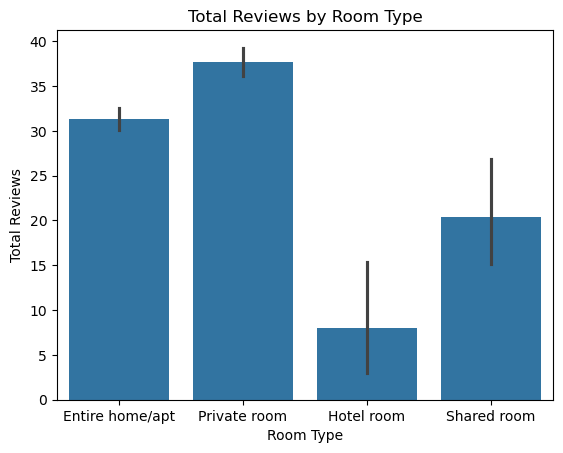

In [44]:
sns.barplot(x='room_type', y='number_of_reviews', data=data)

plt.title("Total Reviews by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Total Reviews")

plt.show()

分析表明，整套住宅/公寓收到的评价数量最多，其次是单间。相比之下，酒店房间和合住房间收到的评价数量明显较少，这表明它们在客人中的受欢迎程度较低。
The analysis shows that entire homes/apartments receive the highest number of reviews, followed by private rooms. In contrast, hotel rooms and shared rooms have significantly fewer reviews, indicating lower popularity among guests.

## 2.2 Most Expensive Room Type


In [38]:
#计算不同房型的平均价格
data.groupby('room_type')['price'].mean()

room_type
Entire home/apt    269.589572
Hotel room         430.036723
Private room       126.238210
Shared room        105.004082
Name: price, dtype: float64

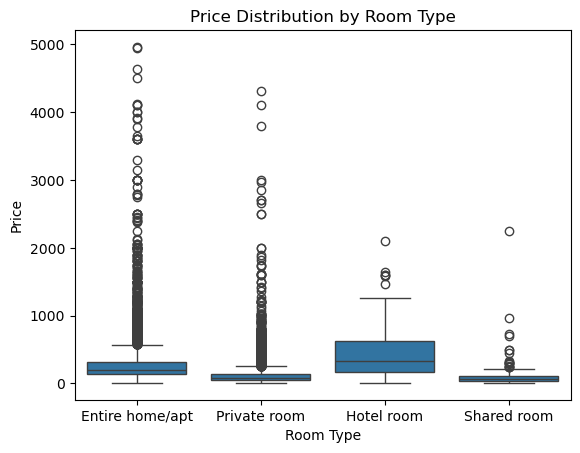

In [39]:
sns.boxplot(x='room_type', y='price', data=data)

plt.title("Price Distribution by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Price")

plt.show()

酒店房和整套房通常更贵，而共享房和独立房间更便宜。
The boxplot shows that price varies across room types. Hotel rooms tend to have the highest prices, followed by entire homes/apartments. Private rooms and shared rooms are generally more affordable. Some extreme price values are also observed.

## 2.3 Neighbourhood Group with Most Listings


In [46]:
#社区统计，我们要看看哪个社区房源最多
data['neighbourhood_group'].value_counts()

neighbourhood_group
Manhattan        9913
Brooklyn         7990
Queens           3557
Bronx             950
Staten Island     316
Name: count, dtype: int64

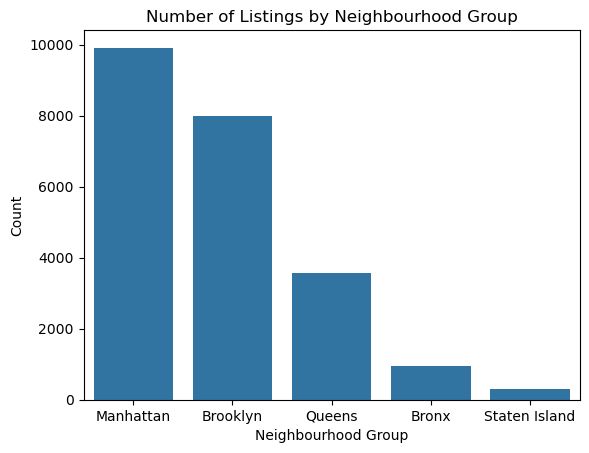

In [47]:
sns.countplot(x='neighbourhood_group', data=data)

plt.title("Number of Listings by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Count")

plt.show()

分析表明，曼哈顿的爱彼迎房源数量最多，其次是布鲁克林。皇后区的房源数量适中，而布朗克斯区和斯塔滕岛的房源数量则明显较少。
The analysis shows that Manhattan has the highest number of Airbnb listings, followed by Brooklyn. Queens has a moderate number of listings, while Bronx and Staten Island have significantly fewer properties available.

## 2.4 Distribution of Room Types Across Neighbourhoods
我们要看房源类型在不同社区是否均匀？

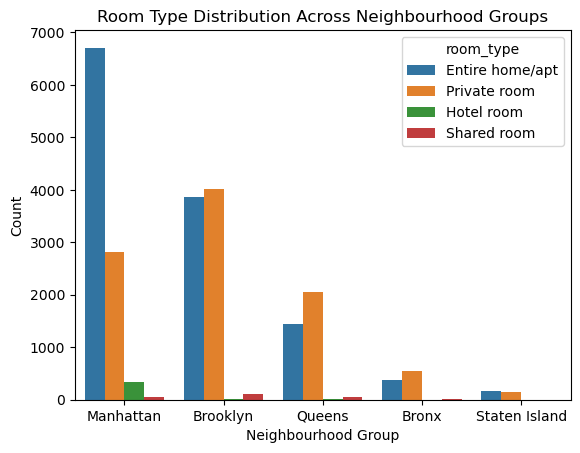

In [49]:
sns.countplot(x='neighbourhood_group', hue='room_type', data=data)

plt.title("Room Type Distribution Across Neighbourhood Groups")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Count")

plt.show()

曼哈顿以整套房屋为主，而布鲁克林的私人房间更多，其他街区的房源总体较少。
Manhattan is dominated by entire homes, while Brooklyn has more private rooms, and other neighbourhoods have fewer listings overall.

## 2.5 Predicting Listing Prices
来了来了预测价格

In [54]:
import pandas as pd
import statsmodels.api as sm

# 选择变量
X = data[['minimum_nights','availability_365','review_activity','room_type','neighbourhood_group']]

# 分类变量转 dummy
X = pd.get_dummies(X, drop_first=True)

# 把所有列变成 numeric
X = X.astype(float)

y = data['log_price']
# 加常数项
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.379
Model:                            OLS   Adj. R-squared:                  0.379
Method:                 Least Squares   F-statistic:                     1389.
Date:                Sat, 07 Mar 2026   Prob (F-statistic):               0.00
Time:                        03:17:00   Log-Likelihood:                -21093.
No. Observations:               22726   AIC:                         4.221e+04
Df Residuals:                   22715   BIC:                         4.230e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

回归结果表明，房型和所在街区位置是影响爱彼迎（Airbnb）价格的最主要因素。位于曼哈顿的房源以及整套房屋的价格往往更高，而私人房间和共享房间则明显更便宜。对价格进行对数转换提高了模型的拟合度，并减少了数据的偏度。
The regression results show that room type and neighbourhood location are the most influential factors affecting Airbnb prices. Listings located in Manhattan and entire homes tend to have higher prices, while private rooms and shared rooms are significantly cheaper. The logarithmic transformation of price improved the model fit and reduced skewness in the data.

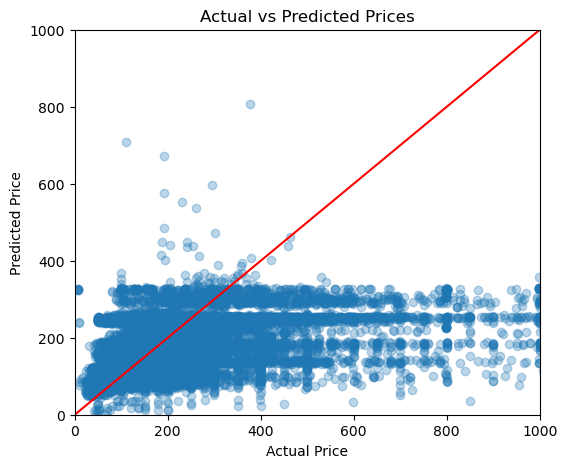

In [57]:
plt.figure(figsize=(6,5))

predicted = np.exp(model.predict(X))
actual = data['price']

plt.scatter(actual, predicted, alpha=0.3)

plt.plot([0,1000],[0,1000], color='red')

plt.xlim(0,1000)
plt.ylim(0,1000)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

plt.show()

哈哈哈哈好吧这模型拉完了就是不能用price得用log_price

R² score: 0.6211640394361833


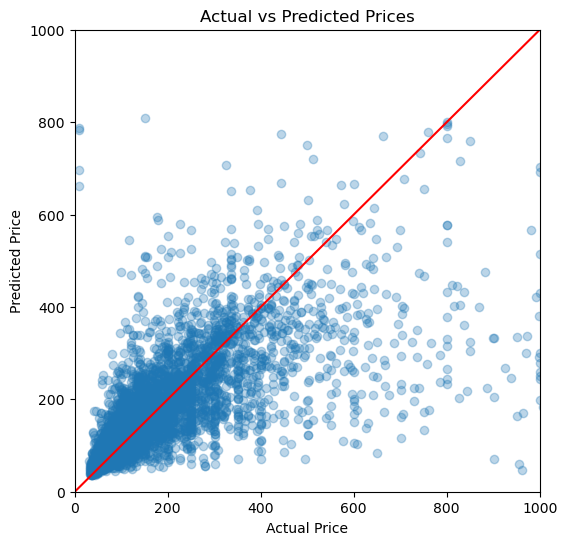

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

features = [
    'minimum_nights',
    'availability_365',
    'review_activity',
    'latitude',
    'longitude',
    'room_type',
    'neighbourhood_group'
]
#诸如房间类型、所在社区位置以及地理坐标等特征之所以被选中，是因为预计它们会对房源价格产生重大影响。
#Features such as room type, neighbourhood location, and geographic coordinates were selected because they are expected to have a strong influence on listing prices۔
X = data[features]

# 分类变量转 dummy
X = pd.get_dummies(X, drop_first=True)

# 预测 log price
y = data['log_price']

# 3 划分训练集 / 测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Random Forest 模型
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)


# 预测
y_pred_log = model.predict(X_test)

# 转回真实价格
y_pred = np.exp(y_pred_log)
y_actual = np.exp(y_test)

# 评价模型

r2 = r2_score(y_test, y_pred_log)

print("R² score:", r2)

#  图片展示

plt.figure(figsize=(6,6))

plt.scatter(y_actual, y_pred, alpha=0.3)
#理想红线
plt.plot([0,1000],[0,1000], color='red')

plt.xlim(0,1000)
plt.ylim(0,1000)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

plt.show()

该模型对爱彼迎的价格预测得相当不错（R² ≈ 0.62），不过高价房源的价格更难准确估算。
The model predicts Airbnb prices reasonably well (R² ≈ 0.62), though high-priced listings are harder to estimate accurately.

# 3.Statistical Analysis and Data Visualization

## 3.1 Model Performance Across Months

In [63]:
months = ['02','03','04','05','06','07','08','09','10','11']

dfs = []

for m in months:
    df = pd.read_csv(f"listings_summary_2024_{m}.csv")
    df['month'] = m
    dfs.append(df)

data_all = pd.concat(dfs, ignore_index=True)

In [64]:
#每个月 + 每个 neighbourhood_group 平均价格
price_trend = data_all.groupby(
    ['month','neighbourhood_group']
)['price'].mean().reset_index()

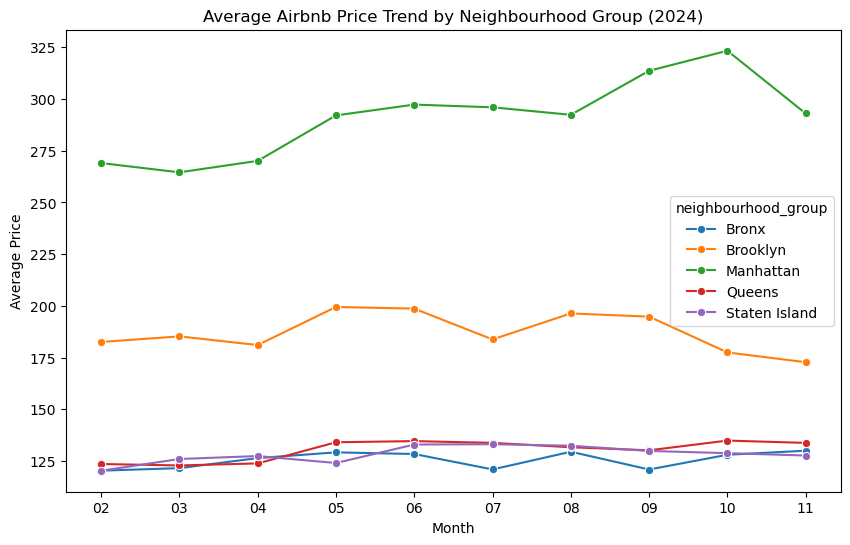

In [65]:
#画 2024 价格趋势
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.lineplot(
    data=price_trend,
    x='month',
    y='price',
    hue='neighbourhood_group',
    marker='o'
)

plt.title("Average Airbnb Price Trend by Neighbourhood Group (2024)")
plt.xlabel("Month")
plt.ylabel("Average Price")

plt.show()

In [66]:
#训练模型预测 price
features = [
    'minimum_nights',
    'availability_365',
    'reviews_per_month',
    'latitude',
    'longitude',
    'room_type',
    'neighbourhood_group'
]

X = data_all[features]
y = data_all['price']

X = pd.get_dummies(X, drop_first=True)

In [67]:
train = data_all[data_all['month'] != '11']
test = data_all[data_all['month'] == '11']

X_train = train[features]
y_train = train['price']

X_test = test[features]
y_test = test['price']

X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [71]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print(X_train.dtypes)

X_train shape: (343098, 12)
y_train shape: (343098,)
minimum_nights                       float64
availability_365                     float64
reviews_per_month                    float64
latitude                             float64
longitude                            float64
room_type_Hotel room                 float64
room_type_Private room               float64
room_type_Shared room                float64
neighbourhood_group_Brooklyn         float64
neighbourhood_group_Manhattan        float64
neighbourhood_group_Queens           float64
neighbourhood_group_Staten Island    float64
dtype: object


In [72]:
print("NaN in X_train:", X_train.isnull().sum().sum())
print("NaN in y_train:", y_train.isnull().sum())

NaN in X_train: 0
NaN in y_train: 132126


In [75]:
#数据清洗
data_all = data_all.dropna(subset=['price'])

In [79]:
print("NaN in y_train:", y_train.isnull().sum())

NaN in y_train: 0


In [76]:
#训练模型
# 2 再拆分 train/test
train = data_all[data_all['month'] != '11']
test = data_all[data_all['month'] == '11']

# 3 再做特征
X_train = train[features]
y_train = train['price']

X_test = test[features]
y_test = test['price']

In [77]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [78]:
model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [80]:
pred = model.predict(X_test)

In [81]:
print("November prediction R²:", r2_score(y_test, pred))

November prediction R²: 0.8219644538996015


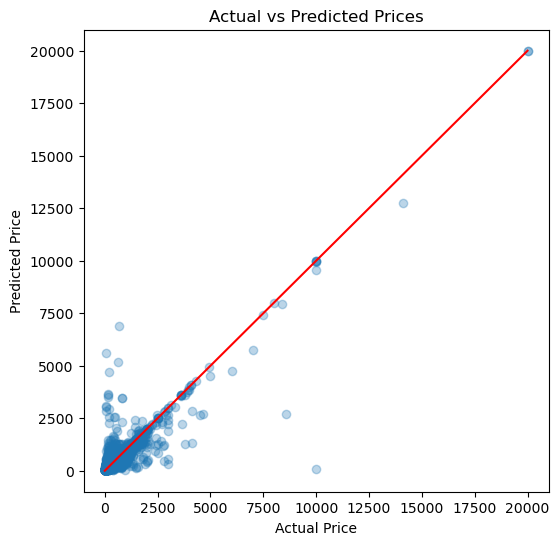

In [83]:
#画预测结果
plt.figure(figsize=(6,6))

plt.scatter(y_test, pred, alpha=0.3)

max_price = max(y_test.max(), pred.max())
plt.plot([0, max_price], [0, max_price], color='red')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.show()

预测的价格总体上与实际价格相符，这表明该模型表现良好，尽管对于高价房源存在一些较大的误差。
The predicted prices generally follow the actual prices, indicating that the model performs reasonably well, although some large errors exist for high-priced listings.

## 3.2 Price Trends by Neighbourhood Group

In [84]:
#按neighbourhood_group计算社区平均价格
avg_price = data_all.groupby(['month','neighbourhood_group'])['price'].mean().reset_index()

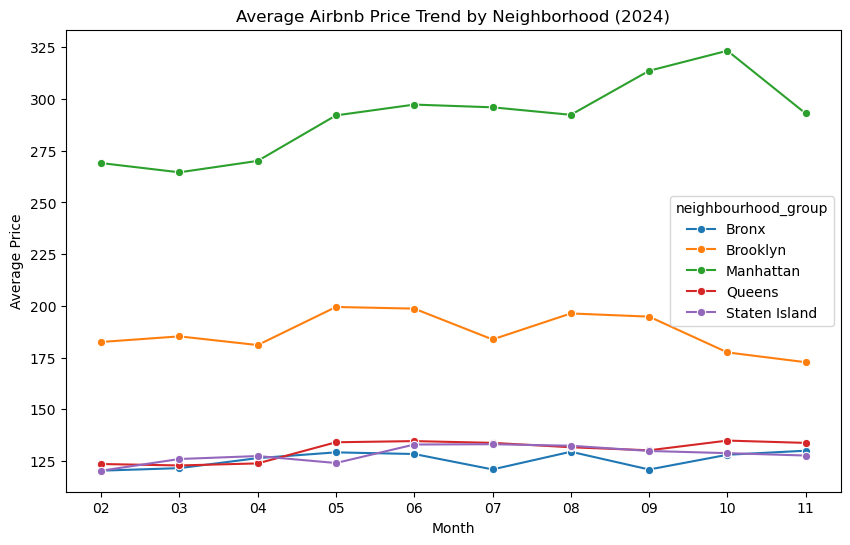

In [85]:
#画趋势图
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.lineplot(
    data=avg_price,
    x='month',
    y='price',
    hue='neighbourhood_group',
    marker='o'
)

plt.title("Average Airbnb Price Trend by Neighborhood (2024)")
plt.xlabel("Month")
plt.ylabel("Average Price")

plt.show()

2024年Manhattan的平均房价始终最高，而其他区域（Bronx、Queens、Staten Island等）价格较低且整体较稳定。
Manhattan has the highest average Airbnb prices throughout 2024, while other neighborhoods show relatively lower and more stable price trends.

## 3.3 Predicting November Prices Using Historical Data

In [86]:
#用 202402–202410 训练模型 → 预测 202411
#1 选训练和测试
train = data_all[(data_all['month'] >= '02') & (data_all['month'] <= '10')]
test = data_all[data_all['month'] == '11']

In [87]:
#2 特征
features = [
    'minimum_nights',
    'availability_365',
    'reviews_per_month',
    'latitude',
    'longitude',
    'room_type',
    'neighbourhood_group'
]
#3 构建训练数据
X_train = train[features]
y_train = train['price']

X_test = test[features]
y_test = test['price']
#4 one-hot编码
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [88]:
#训练模型
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [89]:
#预测11月
pred = model.predict(X_test)

print("November prediction R²:", r2_score(y_test, pred))

November prediction R²: 0.8219644538996015


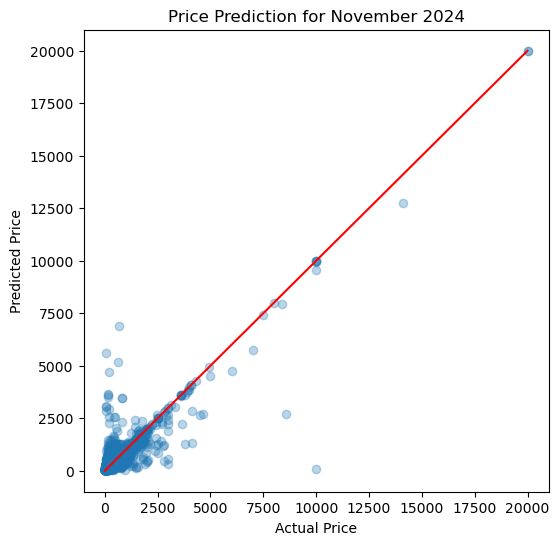

In [90]:
#画预测图
plt.figure(figsize=(6,6))

plt.scatter(y_test, pred, alpha=0.3)

max_price = max(y_test.max(), pred.max())
plt.plot([0, max_price], [0, max_price], color='red')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Price Prediction for November 2024")

plt.show()

11月数据存在，但在模型训练过程中没有使用，因此可以作为测试数据，用于比较预测价格与真实价格，从而评估模型性能。
The scatter plot compares predicted and actual Airbnb prices, showing that the Random Forest model achieves good predictive performance overall.

# 4. Statistical Analysis and Data Visualization (2019 vs 2024 Comparison)

## 4.1 Average Price Trend by Neighborhood in 2019

In [91]:
#读数据
data_2019 = pd.read_csv("listings_summary_2019_00.csv")

In [92]:
#提取月份
data_2019['last_review'] = pd.to_datetime(data_2019['last_review'])
data_2019['month'] = data_2019['last_review'].dt.month

In [93]:
#平均价格
avg_price_2019 = data_2019.groupby(['month','neighbourhood_group'])['price'].mean().reset_index()

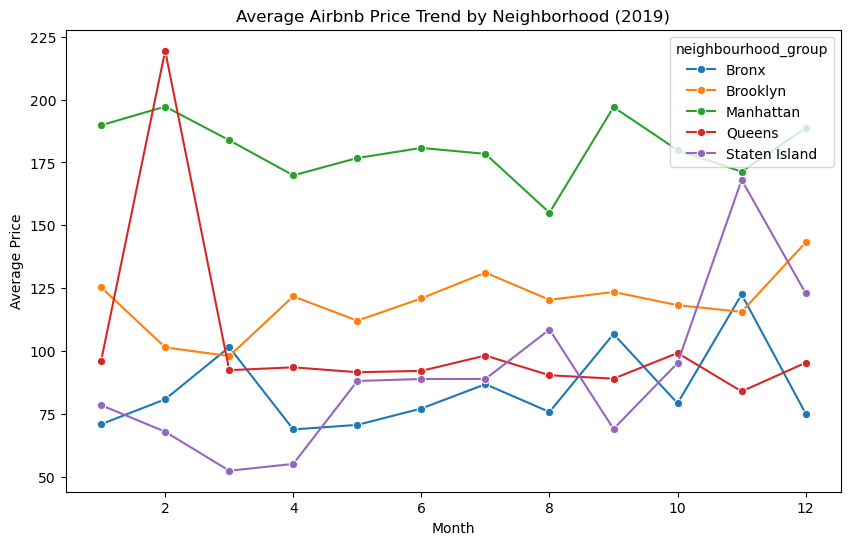

In [94]:
#画图
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.lineplot(
    data=avg_price_2019,
    x='month',
    y='price',
    hue='neighbourhood_group',
    marker='o'
)

plt.title("Average Airbnb Price Trend by Neighborhood (2019)")
plt.xlabel("Month")
plt.ylabel("Average Price")

plt.show()

2019 年，曼哈顿的爱彼迎平均价格一直居高不下，而布朗克斯、布鲁克林和皇后区等其他地区的房价则更低且更稳定。
Manhattan maintains the highest average Airbnb prices throughout 2019, while other neighborhoods such as Bronx, Brooklyn, and Queens have lower and more stable price trends.

## 4.2 Room Type Distribution Comparison (2019 vs 2024)

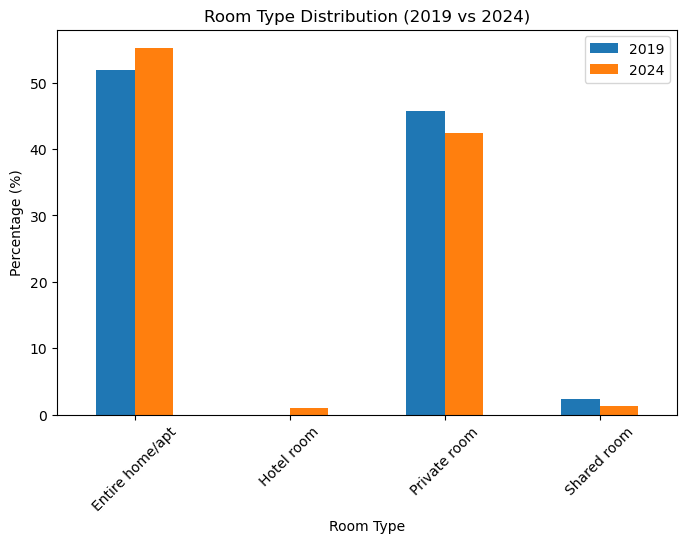

In [96]:
#对比房型
room_2019 = data_2019['room_type'].value_counts(normalize=True) * 100
room_2024 = data_all['room_type'].value_counts(normalize=True) * 100

room_compare = pd.DataFrame({
    '2019': room_2019,
    '2024': room_2024
})

room_compare.plot(kind='bar', figsize=(8,5))

plt.title("Room Type Distribution (2019 vs 2024)")
plt.ylabel("Percentage (%)")
plt.xlabel("Room Type")
plt.xticks(rotation=45)
plt.show()

## 4.3 Price Comparison Between 2019 and 2024

In [97]:
#比较价格
#1.计算平均价格
avg_price_2019 = data_2019['price'].mean()
avg_price_2024 = data_all['price'].mean()

print("2019 Average Price:", avg_price_2019)
print("2024 Average Price:", avg_price_2024)

2019 Average Price: 152.7206871868289
2024 Average Price: 219.36069880580027


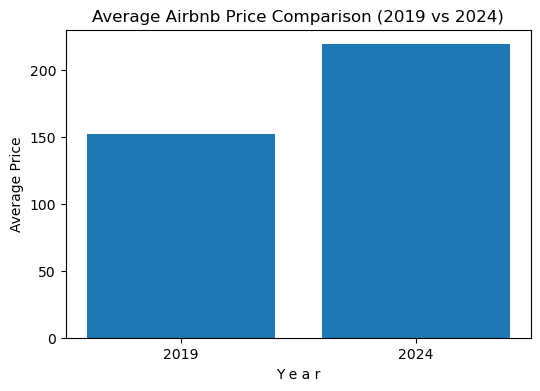

In [100]:
#画图对比
price_compare = pd.DataFrame({
    'Year': ['2019','2024'],
    'Average Price': [avg_price_2019, avg_price_2024]
})

plt.figure(figsize=(6,4))

plt.bar(price_compare['Year'], price_compare['Average Price'])

plt.title("Average Airbnb Price Comparison (2019 vs 2024)")
plt.xlabel("Y e a r")
plt.ylabel("Average Price")

plt.show()

2024年的Airbnb平均房价高于2019年，表明房价整体呈上升趋势
The average Airbnb price in 2024 is higher than in 2019, indicating an overall increase in listing prices over time.

# 5.summary

这项分析研究了 2019 年和 2024 年爱彼迎的房源数据，以识别定价模式和市场变化。结果表明，曼哈顿的平均价格一直最高，而其他社区的价格水平则相对较低。在两年中，整套住宅/公寓和私人房间在爱彼迎市场中占据主导地位。此外，2024 年的平均挂牌价格略高于 2019 年，这表明爱彼迎的价格总体上呈上升趋势。
This analysis explored Airbnb listing data from 2019 and 2024 to identify pricing patterns and market changes. The results show that Manhattan consistently has the highest average prices, while other neighborhoods maintain relatively lower price levels. Entire homes/apartments and private rooms dominate the Airbnb market in both years. Additionally, the average listing price in 2024 is slightly higher than in 2019, indicating a general increase in Airbnb prices over time.